In [77]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import contextily as ctx
from shapely.geometry import Point
from adjustText import adjust_text

df = pd.read_pickle("mercatini.pickle")

colori = sns.color_palette("pastel")

df

,stagione,evento,luogo,n giorni,lat,long
0,est 2024,rievocazione storica,romans d'isonzo,2,45.883016,13.446230
1,inv 2024,mercatino di Natale,gradisca d'isonzo,1,45.888481,13.501034
2,aut 2025,festa del solstizio,aquileia,1,45.772453,13.366816
3,prim 2026,festa del solstizio,aquileia,1,45.772453,13.366816
4,est 2026,rievocazione storica,romans d'isonzo,2,45.883016,13.446230


In [90]:
df_eventi = df.groupby(["evento", "lat", "long"], as_index=False)["n giorni"].sum()
df_eventi

,evento,lat,long,n giorni
0,festa del solstizio,45.772453,13.366816,2
1,mercatino di Natale,45.888481,13.501034,1
2,rievocazione storica,45.883016,13.446230,4


In [91]:
gdf = gpd.GeoDataFrame(
    df_eventi,
    crs="EPSG:4326",
    geometry=gpd.points_from_xy(df_eventi["long"], df_eventi["lat"])
)

gdf = gdf.to_crs(epsg=3857)
gdf

,evento,lat,long,n giorni,geometry
0,festa del solstizio,45.772453,13.366816,2,POINT (1487987.195 5743959.287)
1,mercatino di Natale,45.888481,13.501034,1,POINT (1502928.174 5762496.213)
2,rievocazione storica,45.883016,13.446230,4,POINT (1496827.477 5761622.262)


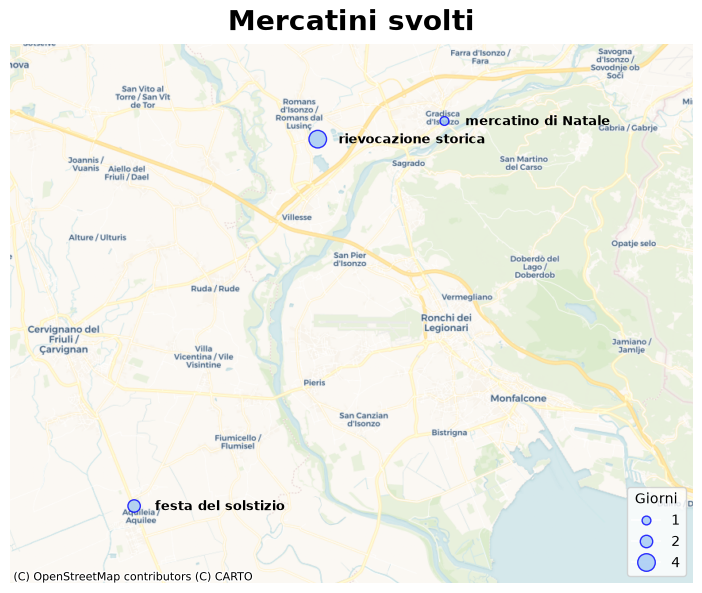

In [172]:
fig, ax = plt.subplots(figsize=(10, 7))

gdf.plot(ax=ax, color=colori[0], markersize=gdf["n giorni"]*40, alpha=0.8, edgecolor="blue" )

for x, y, label in zip( gdf.geometry.x, gdf.geometry.y, gdf["evento"] ):
    ax.text(x + 1000, y - 200, label, fontsize=9, fontweight="bold")

from matplotlib.lines import Line2D

valori_legenda = [1, 2, 4]
handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=colori[0],
           markersize=(v*40)**0.5, label=v, alpha=0.8, markeredgecolor="blue")
    for v in valori_legenda
]
ax.legend(handles=handles, title="Giorni", loc="lower right")

minx, miny, maxx, maxy = gdf.total_bounds
dx = (maxx - minx) * 0.4
dy = (maxy - miny) * 0.2
ax.set_xlim(minx - dx, maxx + dx*2)
ax.set_ylim(miny - dy, maxy + dy)

ctx.add_basemap(ax, source=ctx.providers.CartoDB.Voyager)

ax.set_title("Mercatini svolti", pad=10, fontsize=20, fontweight="bold")
ax.set_axis_off()

plt.savefig("Immagini/Mappa.svg", bbox_inches="tight", pad_inches=0.1, transparent=False)
plt.savefig("Immagini/Mappa.png", bbox_inches="tight", pad_inches=0.1, transparent=False)